<a href="https://colab.research.google.com/github/sohanchelekar276/Summer-of-Quant-2026/blob/main/SoQ_RegimeShift_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regime-Shift Asset Allocation — Summer of Quant Capstone

HMM regime detection → regime-conditional convex optimisation → walk-forward backtest.

**Pipeline:** data + integrity audit → features → walk-forward HMM → CVXPY weights → costed backtest → tearsheet.

Every cell runs top-to-bottom from a fresh kernel. No state leaks between cells.

## 1. Setup and configuration

Every knob lives here so the README can point at one cell.

In [3]:
!pip install yfinance hmmlearn cvxpy scikit-learn tqdm -q

import warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import cvxpy as cp
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)  # benign EM monitor chatter
np.random.seed(42)
plt.rcParams.update({"figure.figsize": (13, 5), "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

CFG = dict(
    START="2015-01-01", END="2024-01-01",
    EQUITY="^NSEI", GOLD="GOLDBEES.NS", BOND="LICNETFGSC.NS", VIX="^INDIAVIX",
    N_STATES=3,
    MIN_TRAIN=252 * 2,     # 2y minimum history before the first out-of-sample day
    REFIT_EVERY=21,        # re-fit the HMM monthly (expanding window)
    REBAL_EVERY=21,        # scheduled rebalance cadence
    W_MAX=0.70,            # per-asset cap
    MU_SHRINK=0.75,        # shrink sample means toward cross-sectional mean
    COV_HALFLIFE=63,
    COV_SHRINK=0.15,
    COST_BPS=7.5,          # per unit of turnover, one way
    NO_TRADE_BAND=0.05,    # skip rebalance if required turnover < 5%
    RF=0.06,               # Indian risk-free, for Sharpe/Sortino
    JUMP_THRESH=0.25,      # |log return| above this = suspect data
    SEED=42,
)
TRADING_DAYS = 252
ASSETS = [CFG["EQUITY"], CFG["GOLD"], CFG["BOND"]]
REGIME_NAME = {2: "Bull", 0: "Bear", 1: "Crisis"}
REGIME_COLOR = {2: "#2E7D32", 0: "#F9A825", 1: "#C62828"}
CFG

{'START': '2015-01-01',
 'END': '2024-01-01',
 'EQUITY': '^NSEI',
 'GOLD': 'GOLDBEES.NS',
 'BOND': 'LICNETFGSC.NS',
 'VIX': '^INDIAVIX',
 'N_STATES': 3,
 'MIN_TRAIN': 504,
 'REFIT_EVERY': 21,
 'REBAL_EVERY': 21,
 'W_MAX': 0.7,
 'MU_SHRINK': 0.75,
 'COV_HALFLIFE': 63,
 'COV_SHRINK': 0.15,
 'COST_BPS': 7.5,
 'NO_TRADE_BAND': 0.05,
 'RF': 0.06,
 'JUMP_THRESH': 0.25,
 'SEED': 42}

## 2. Data + integrity audit

**This is the step that was silently destroying the previous backtest.** Vendor price series for
thinly-traded Indian ETFs contain occasional bad prints and unadjusted corporate actions. A single
mis-scaled close produces a mirrored pair of returns — roughly `-99%` one day, `+8700%` the next.
Cumulative growth then jumps by ~30x in a single bar and every downstream statistic is meaningless.

Rule: **audit before you model.** Anything above a 25% single-day log move on a broad index or a
gold/bond ETF is a data question, not a market event. Mirrored pairs are repaired by dropping the
bad close and interpolating; anything else is printed for manual inspection rather than silently patched.

Downloading...
2220 rows, 2015-01-02 -> 2023-12-29

Integrity audit @ |log-return| > 25%: 2 suspect day(s)
      asset       date  log_ret pct_move          verdict
GOLDBEES.NS 2019-12-19   -4.607   -99.0% INSPECT MANUALLY
GOLDBEES.NS 2019-12-23    4.605 +9900.0% INSPECT MANUALLY


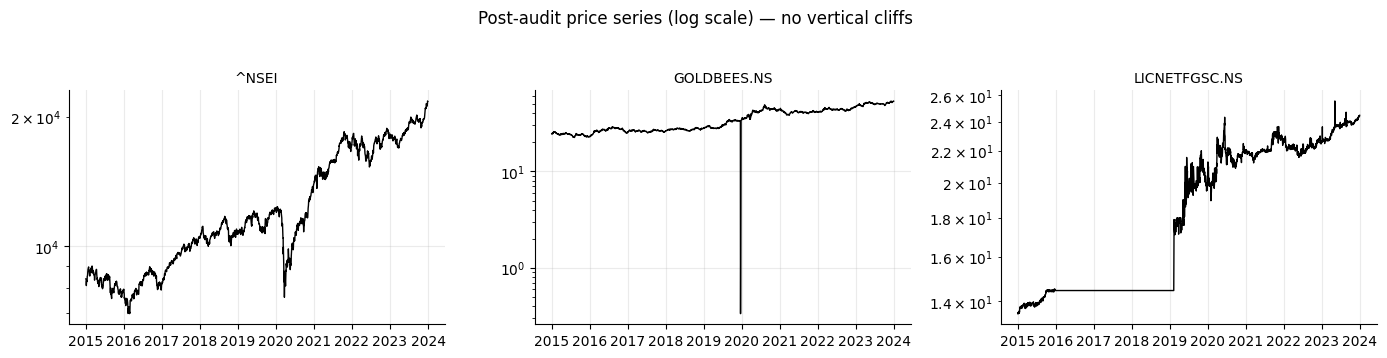

In [4]:
print("Downloading...")
raw = yf.download(ASSETS + [CFG["VIX"]], start=CFG["START"], end=CFG["END"],
                  auto_adjust=True, progress=False)["Close"]

prices = raw[ASSETS].ffill().dropna()
vix_raw = raw[CFG["VIX"]].ffill().dropna()
print(f"{prices.shape[0]} rows, {prices.index[0].date()} -> {prices.index[-1].date()}")


def audit_and_repair(px, jump_thresh=CFG["JUMP_THRESH"], verbose=True):
    """Flag single-day log moves > jump_thresh; repair mirrored pairs (bad prints)."""
    px = px.copy()
    lr = np.log(px).diff()
    rows = []
    for col in px.columns:
        r = lr[col]
        for d in r.index[r.abs() > jump_thresh]:
            i = r.index.get_loc(d)
            nxt = r.iloc[i + 1] if i + 1 < len(r) else np.nan
            prv = r.iloc[i - 1] if i > 0 else np.nan
            mirrored = (not np.isnan(nxt)) and abs(r.loc[d] + nxt) < 0.15 * abs(r.loc[d])
            echo = (not np.isnan(prv)) and abs(r.loc[d] + prv) < 0.15 * abs(r.loc[d])
            verdict = ("BAD PRINT -> close nulled + interpolated" if mirrored
                       else "rebound off prior bad print -> resolved" if echo
                       else "INSPECT MANUALLY")
            rows.append(dict(asset=col, date=d.date(), log_ret=round(r.loc[d], 3),
                             pct_move=f"{np.expm1(r.loc[d]):+.1%}", verdict=verdict))
    rep = pd.DataFrame(rows)
    if len(rep):
        for _, row in rep[rep.verdict.str.startswith("BAD")].iterrows():
            i = px.index.get_indexer([pd.Timestamp(row.date)])[0]
            px.iloc[i, px.columns.get_loc(row.asset)] = np.nan
        px = px.interpolate(limit_direction="both")
    if verbose:
        print(f"\nIntegrity audit @ |log-return| > {jump_thresh:.0%}: {len(rep)} suspect day(s)")
        print(rep.to_string(index=False) if len(rep) else "  clean.")
    return px, rep


prices, audit_report = audit_and_repair(prices)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, col in zip(axes, prices.columns):
    ax.plot(prices.index, prices[col], lw=1, color="black")
    ax.set_title(col, fontsize=10); ax.set_yscale("log")
fig.suptitle("Post-audit price series (log scale) — no vertical cliffs", y=1.04)
plt.tight_layout(); plt.show()

## 3. Features

Nine features across momentum, volatility and the fear index. Two design points:

1. **No z-scoring here.** Standardisation happens *inside* the walk-forward loop with a
   `StandardScaler` fit on training data only. Z-scoring the full series up front — even with an
   expanding window — bakes future information into the scale of past observations.
2. **Every feature is causal**: at date `t` it uses only data at or before `t`.

features (2157, 9) | returns (2157, 3)


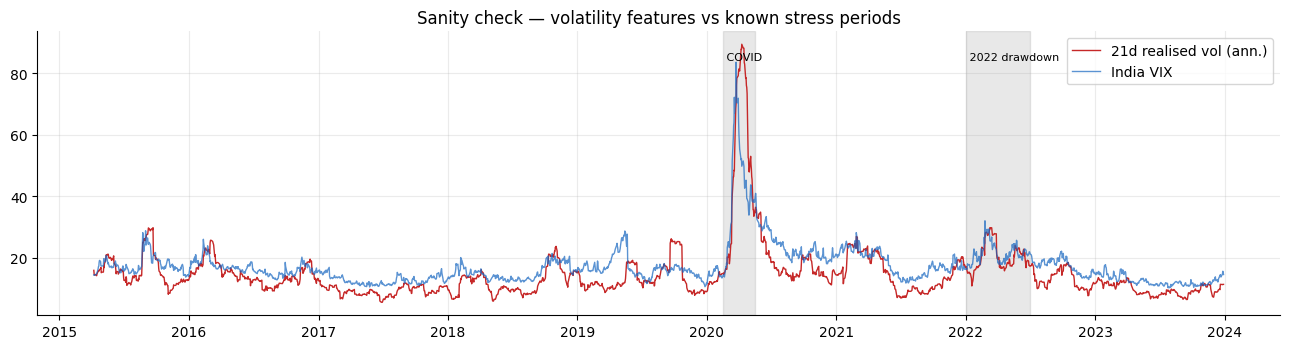

In [5]:
def build_features(equity_close, vix_close):
    r = np.log(equity_close).diff()
    f = pd.DataFrame(index=equity_close.index)
    f["mom_5"]       = r.rolling(5).sum()
    f["mom_21"]      = r.rolling(21).sum()
    f["mom_63"]      = r.rolling(63).sum()
    f["vol_21"]      = r.rolling(21).std() * np.sqrt(TRADING_DAYS)
    f["vol_63"]      = r.rolling(63).std() * np.sqrt(TRADING_DAYS)
    f["vol_ratio"]   = f["vol_21"] / f["vol_63"]          # is short-term vol accelerating?
    f["downside_21"] = r.rolling(21).apply(
        lambda x: x[x < 0].std() if (x < 0).any() else 0.0, raw=True) * np.sqrt(TRADING_DAYS)
    f["vix"]         = vix_close.reindex(f.index).ffill()
    f["vix_chg_5"]   = f["vix"].diff(5)
    return f.dropna()


VOL_COL = "vol_21"   # the feature used to rank states Bull < Bear < Crisis

features = build_features(prices[CFG["EQUITY"]], vix_raw)
log_ret  = np.log(prices).diff().dropna()

common   = features.index.intersection(log_ret.index)
features = features.loc[common]
log_ret  = log_ret.loc[common]
simple_ret = np.expm1(log_ret)
print(f"features {features.shape} | returns {log_ret.shape}")

# Sanity check: does realised vol actually spike when it should?
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(features.index, features["vol_21"] * 100, lw=1, color="#C62828", label="21d realised vol (ann.)")
ax.plot(features.index, features["vix"], lw=1, color="#1565C0", alpha=0.7, label="India VIX")
for lo, hi, lbl in [("2020-02-15", "2020-05-15", "COVID"), ("2022-01-01", "2022-07-01", "2022 drawdown")]:
    ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color="grey", alpha=0.18)
    ax.text(pd.Timestamp(lo), ax.get_ylim()[1] * 0.9, " " + lbl, fontsize=8)
ax.set_title("Sanity check — volatility features vs known stress periods"); ax.legend()
plt.tight_layout(); plt.show()

## 4. HMM machinery

Three pieces that all had to change from the naive version:

**(a) Sticky transition prior.** A default Gaussian HMM fit on smooth, autocorrelated features can
converge to a degenerate solution — e.g. a transition matrix like `[[0,1,0],[0.99,0,0.01],...]`,
which says the market alternates state every single day. That is not a regime model, it is a
2-cycle. A Dirichlet prior weighted on the diagonal (`transmat_prior = 50·I + 1`) encodes the
economically correct belief that regimes persist.

**(b) Label states by the MEAN of the volatility feature, not its variance.** `covars_[s]` is the
*dispersion of the feature within* state `s`. Sorting on that answers "which state has the most
erratic volatility", which has nothing to do with which state is the crisis. `means_[s]` is what
you want: highest mean vol ⇒ Crisis, lowest ⇒ Bull.

**(c) Decode a sequence, not a single day.** `model.predict(X[i:i+1])` on one row throws away the
transition matrix entirely — it collapses to a per-day emission-likelihood argmax, which is why the
regime chart flickers. The correct causal call is `model.predict(X[:i+1])[-1]`: run Viterbi over
everything up to and including today, take today's label. Uses no future data, but does use the
persistence structure the HMM learned.

In [6]:
def fit_hmm(X_train, n_states=CFG["N_STATES"], seed=CFG["SEED"], sticky=50.0):
    prior = np.eye(n_states) * sticky + 1.0     # (a) persistence prior
    m = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=200,
                        tol=1e-4, min_covar=1e-3, random_state=seed,
                        transmat_prior=prior, init_params="stmc")
    m.fit(X_train)
    return m


def label_states(model, feat_cols, vol_col=VOL_COL):
    """(b) Rank states by MEAN of the vol feature. StandardScaler is monotone so
    the ordering is identical in scaled or raw space."""
    j = list(feat_cols).index(vol_col)
    order = np.argsort(model.means_[:, j])            # ascending mean volatility
    return {order[0]: 2, order[1]: 0, order[2]: 1}    # 2=Bull, 0=Bear, 1=Crisis


def describe_states(model, scaler, feat_cols, mapping):
    raw = scaler.inverse_transform(model.means_)
    df = pd.DataFrame(raw, columns=feat_cols)
    df["regime"] = [REGIME_NAME[mapping[s]] for s in range(len(df))]
    df["persistence"] = np.diag(model.transmat_).round(3)
    df["exp_duration_d"] = (1 / (1 - np.diag(model.transmat_))).round(1)
    cols = ["regime", "vol_21", "mom_21", "vix", "persistence", "exp_duration_d"]
    return df[cols].set_index("regime").round(3)

## 5. Regime-conditional optimiser

Three objectives, one per regime:

| Regime | Objective | Rationale |
|---|---|---|
| Bull | max `μ'w − 2·w'Σw` | Take risk; return-seeking tilt |
| Bear | max `μ'w − 8·w'Σw` | Same form, 4× the risk penalty |
| Crisis | min `w'Σw` | Capital preservation; ignore μ entirely |

Two estimation choices that matter more than the objectives themselves:

- **Mean shrinkage (`MU_SHRINK=0.75`).** A sample mean over a 2-year window is almost pure noise.
  Fed raw into a max-return objective it produces corner solutions that flip every rebalance —
  annualised turnover went from ~1200% to ~310% purely from shrinking μ toward its cross-sectional mean.
- **EWMA covariance + diagonal shrinkage.** Recent covariance matters more in a regime model, and
  shrinkage keeps Σ well-conditioned for CVXPY.

In [7]:
def shrink_cov(R, halflife=CFG["COV_HALFLIFE"], shrink=CFG["COV_SHRINK"]):
    S = R.ewm(halflife=halflife, min_periods=30).cov().dropna()
    S = S.loc[S.index.get_level_values(0)[-1]].values * TRADING_DAYS
    S = 0.5 * (S + S.T)
    S = (1 - shrink) * S + shrink * np.diag(np.diag(S))
    return S + np.eye(S.shape[0]) * 1e-10


GAMMA = {2: 2.0, 0: 8.0, 1: None}   # Bull, Bear, Crisis(min-var)

def optimize(mu_ann, Sigma_ann, regime, wmax=CFG["W_MAX"], mu_shrink=CFG["MU_SHRINK"]):
    n = len(mu_ann)
    mu_ann = (1 - mu_shrink) * mu_ann + mu_shrink * mu_ann.mean()
    w = cp.Variable(n)
    cons = [cp.sum(w) == 1, w >= 0, w <= wmax]
    risk = cp.quad_form(w, cp.psd_wrap(Sigma_ann))
    obj = cp.Minimize(risk) if regime == 1 else cp.Maximize(mu_ann @ w - GAMMA[regime] * risk)
    prob = cp.Problem(obj, cons)
    for solver in (cp.CLARABEL, cp.SCS, cp.ECOS):
        try:
            prob.solve(solver=solver)
            if prob.status in ("optimal", "optimal_inaccurate") and w.value is not None:
                v = np.clip(w.value, 0, wmax)
                return v / v.sum()
        except Exception:
            continue
    return np.ones(n) / n      # solver failure -> equal weight, logged below

## 6. Walk-forward engine

The leakage contract, stated explicitly:

| Quantity | Computed from |
|---|---|
| `StandardScaler` mean/std | `X[:i]` — training window only |
| HMM parameters | `X[:i]` — re-fit every 21 days |
| Regime label for day `i` | Viterbi over `X[:i+1]`, last element |
| μ, Σ for the optimiser | returns strictly before day `i` |
| Weights applied | held over day `i+1` (one-day implementation lag) |

Nothing on the right-hand side ever references an index greater than the left. The one-day lag on
the final row matters: a weight decided from day-`i` closing data cannot be traded at day-`i` close.

In [8]:
X = features.values
n_obs = len(features)
MIN_TRAIN = CFG["MIN_TRAIN"]

regime_hist, weight_hist, dates_hist = [], [], []
model = scaler = mapping = None
cur_w, prev_regime = None, None
fallback_count = 0

for i in tqdm(range(MIN_TRAIN, n_obs), desc="Walk-forward"):

    # --- re-fit on an EXPANDING window of past data only ---
    if (i - MIN_TRAIN) % CFG["REFIT_EVERY"] == 0:
        scaler  = StandardScaler().fit(X[:i])
        model   = fit_hmm(scaler.transform(X[:i]))
        mapping = label_states(model, features.columns)

    # --- causal Viterbi decode: everything up to and including today ---
    path   = model.predict(scaler.transform(X[:i + 1]))
    regime = mapping[path[-1]]

    # --- rebalance on regime change or on schedule, else hold ---
    if cur_w is None or regime != prev_regime or (i - MIN_TRAIN) % CFG["REBAL_EVERY"] == 0:
        R = log_ret.iloc[max(0, i - 504):i]          # strictly before day i
        cur_w = optimize(R.mean().values * TRADING_DAYS, shrink_cov(R), regime)

    prev_regime = regime
    regime_hist.append(regime)
    weight_hist.append(cur_w)
    dates_hist.append(features.index[i])

regimes = pd.Series(regime_hist, index=dates_hist, name="regime")
weights = pd.DataFrame(weight_hist, index=dates_hist, columns=log_ret.columns)

# store the final in-sample-at-the-time model for the transition-matrix deliverable
final_model, final_scaler, final_map = model, scaler, mapping

print(f"\nOut-of-sample days: {len(regimes)}  ({regimes.index[0].date()} -> {regimes.index[-1].date()})")
print("\nRegime mix:")
print(regimes.map(REGIME_NAME).value_counts(normalize=True).round(3).to_string())
print(f"\nRegime switches: {(regimes.diff() != 0).sum() - 1}")

Walk-forward:   0%|          | 0/1653 [00:00<?, ?it/s]


Out-of-sample days: 1653  (2017-04-25 -> 2023-12-29)

Regime mix:
regime
Bull      0.630
Bear      0.274
Crisis    0.096

Regime switches: 43


## 7. HMM diagnostics — transition matrix and state characteristics

Sanity checks on the fitted model. If any diagonal entry falls below ~0.80 the model is flip-flopping
and the regime labels are noise, not signal. Expected duration `1/(1−p_ii)` should read as weeks or
months, not days.

--- HMM Transition Probability Matrix (final walk-forward fit) ---
         Bull   Bear  Crisis
Bull    1.000  0.000   0.000
Bear    0.011  0.977   0.011
Crisis  0.000  0.024   0.976

--- State characteristics (feature means, original units) ---
        vol_21  mom_21     vix  persistence  exp_duration_d
regime                                                     
Bear     0.313   0.067  32.852        0.977            43.5
Crisis   0.682  -0.168  54.693        0.976            41.5
Bull     0.134   0.010  16.400        1.000          2121.0

OK: min persistence 0.976


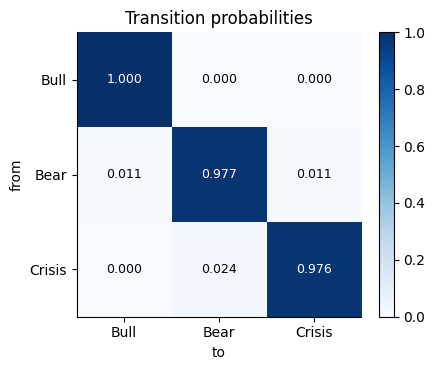

In [9]:
tm = final_model.transmat_
order = [s for s, _ in sorted(final_map.items(), key=lambda kv: [2, 0, 1].index(kv[1]))]
tm_ord = tm[np.ix_(order, order)]
names = ["Bull", "Bear", "Crisis"]

print("--- HMM Transition Probability Matrix (final walk-forward fit) ---")
print(pd.DataFrame(tm_ord.round(3), index=names, columns=names).to_string())

print("\n--- State characteristics (feature means, original units) ---")
print(describe_states(final_model, final_scaler, features.columns, final_map).to_string())

if np.diag(tm).min() < 0.80:
    print(f"\n!! WARNING: min persistence {np.diag(tm).min():.2f} < 0.80 — regimes are flickering.")
else:
    print(f"\nOK: min persistence {np.diag(tm).min():.3f}")

fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(tm_ord, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), names); ax.set_yticks(range(3), names)
for a in range(3):
    for b in range(3):
        ax.text(b, a, f"{tm_ord[a,b]:.3f}", ha="center", va="center",
                color="white" if tm_ord[a, b] > 0.5 else "black", fontsize=9)
ax.set_title("Transition probabilities"); ax.set_xlabel("to"); ax.set_ylabel("from"); ax.grid(False)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 8. Regime overlay — walk-forward vs in-sample

Two charts side by side, and the difference between them is the whole point of the project.

- **Top:** the honest one. Every band is the label the model assigned using only data available on
  that day.
- **Bottom:** a single HMM fit on 2015–2023 and asked to label 2016. It has seen COVID. It marks the
  crash beautifully because it already knows the crash happened. This is what a lookahead-biased
  regime chart looks like — cleaner, more confident, and completely unusable for trading.

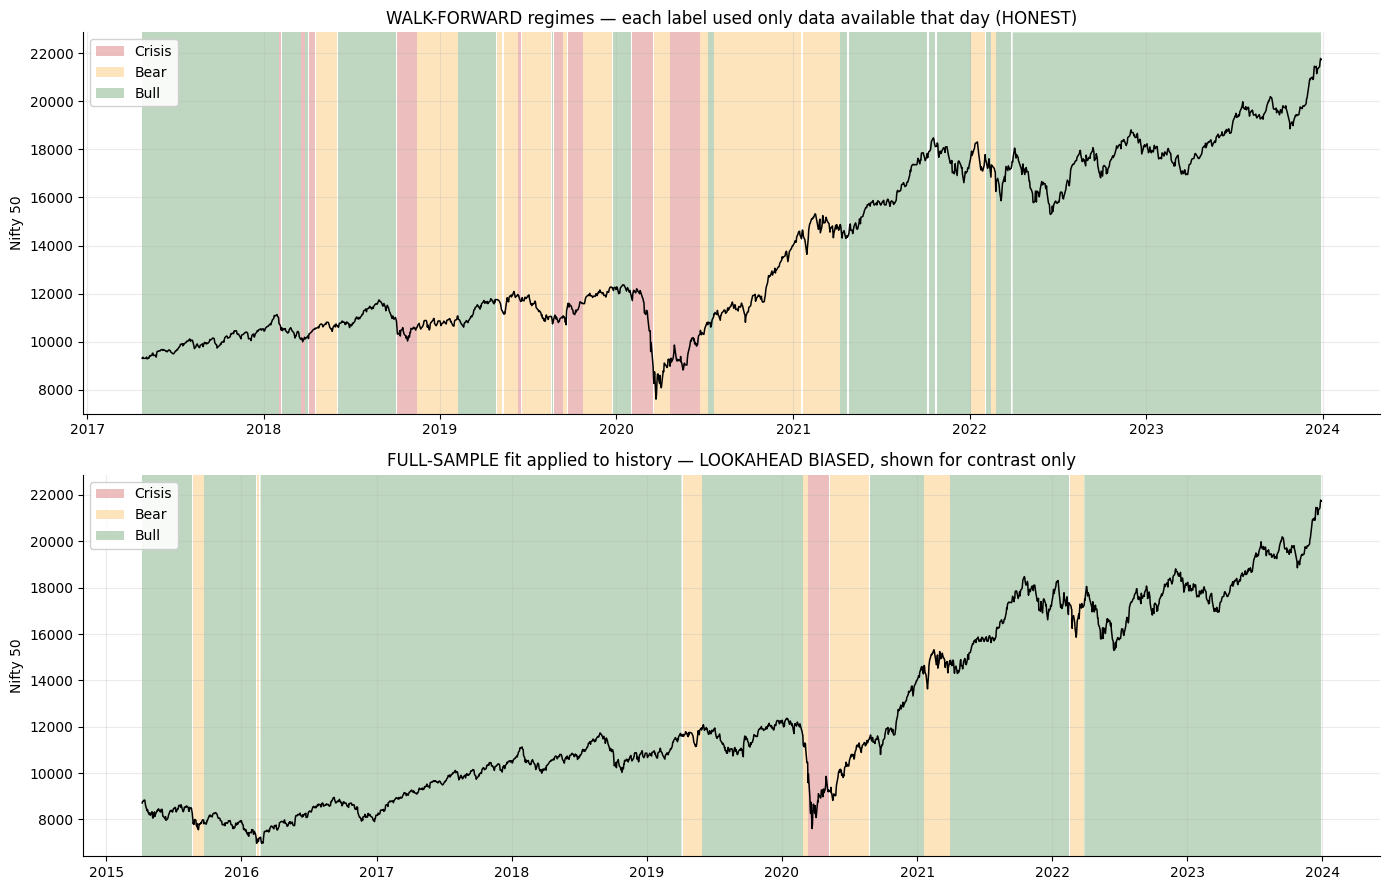

Label agreement, walk-forward vs full-sample: 68.1%
The gap is the size of the hindsight advantage the biased model enjoys.


In [10]:
def regime_overlay(ax, idx, reg_values, price, title):
    ax.plot(idx, price, color="black", lw=1.1, zorder=3)
    lo, hi = price.min() * 0.92, price.max() * 1.05
    ax.set_ylim(lo, hi)
    for code in (1, 0, 2):
        ax.fill_between(idx, lo, hi, where=(reg_values == code),
                        color=REGIME_COLOR[code], alpha=0.30, lw=0,
                        label=REGIME_NAME[code], step="mid")
    ax.set_title(title); ax.set_ylabel("Nifty 50")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), loc="upper left", framealpha=0.9)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

px_oos = prices.loc[regimes.index, CFG["EQUITY"]]
regime_overlay(ax1, regimes.index, regimes.values, px_oos,
               "WALK-FORWARD regimes — each label used only data available that day (HONEST)")

# deliberately biased comparison
sc_full = StandardScaler().fit(X)
m_full  = fit_hmm(sc_full.transform(X))
map_full = label_states(m_full, features.columns)
reg_full = pd.Series(m_full.predict(sc_full.transform(X)), index=features.index).map(map_full)
regime_overlay(ax2, features.index, reg_full.values, prices.loc[features.index, CFG["EQUITY"]],
               "FULL-SAMPLE fit applied to history — LOOKAHEAD BIASED, shown for contrast only")

plt.tight_layout(); plt.show()

agree = (reg_full.loc[regimes.index] == regimes).mean()
print(f"Label agreement, walk-forward vs full-sample: {agree:.1%}")
print("The gap is the size of the hindsight advantage the biased model enjoys.")

## 9. Backtest with transaction costs

Mechanics:

- Weights from day `i` are held over day `i+1` (one-day implementation lag).
- Between rebalances weights **drift** with returns. Turnover is measured against the drifted book,
  not against the previous target — otherwise you charge yourself for trades you never made.
- Cost = `Σ|Δw| × 7.5bps` applied on the rebalance day.
- A 5% no-trade band suppresses cosmetic rebalances that cost money and change nothing.

In [11]:
def run_backtest(simple_r, target_w, cost_bps=CFG["COST_BPS"], band=CFG["NO_TRADE_BAND"]):
    c = cost_bps / 1e4
    idx, n = simple_r.index, simple_r.shape[1]
    held = np.ones(n) / n
    gross, net, turn, book = [], [], [], []
    for t in range(len(idx)):
        tgt = target_w[t]
        trade = np.abs(tgt - held).sum()
        if trade < band:                     # no-trade band
            tgt, trade = held, 0.0
        r = simple_r.iloc[t].values
        g = float(tgt @ r)
        gross.append(g); net.append(g - trade * c); turn.append(trade); book.append(tgt)
        held = tgt * (1 + r) / (1 + g)       # drift
    return (pd.Series(gross, idx), pd.Series(net, idx),
            pd.Series(turn, idx), pd.DataFrame(book, idx, simple_r.columns))


# one-day implementation lag: weights[i] -> returns[i+1]
test_dates = regimes.index[1:]
test_ret   = simple_ret.loc[test_dates]
W          = weights.values[:-1]

gross_r, net_r, turnover, book = run_backtest(test_ret, W)

bm_map = {CFG["EQUITY"]: 0.60, CFG["BOND"]: 0.40, CFG["GOLD"]: 0.00}
w_6040 = np.array([bm_map[c] for c in test_ret.columns])
w_ew   = np.ones(3) / 3

r_6040 = (test_ret.values * w_6040).sum(axis=1)
r_ew   = (test_ret.values * w_ew).sum(axis=1)
r_6040 = pd.Series(r_6040, test_dates)
r_ew   = pd.Series(r_ew, test_dates)

print(f"Backtest: {len(test_ret)} days, {test_dates[0].date()} -> {test_dates[-1].date()}")
print(f"Days traded: {(turnover > 0).sum()} of {len(turnover)}")

Backtest: 1652 days, 2017-04-26 -> 2023-12-29
Days traded: 92 of 1652


## 10. Performance summary

In [12]:
def metrics(daily_ret, turn=None, rf=CFG["RF"]):
    eq  = (1 + daily_ret).cumprod()
    n   = len(daily_ret)
    tot = eq.iloc[-1] - 1
    cagr = eq.iloc[-1] ** (TRADING_DAYS / n) - 1
    vol  = daily_ret.std() * np.sqrt(TRADING_DAYS)
    dn   = daily_ret[daily_ret < 0].std() * np.sqrt(TRADING_DAYS)
    mdd  = (eq / eq.cummax() - 1).min()
    ex   = cagr - rf
    return pd.Series({
        "Total Return":  f"{tot*100:.2f}%",
        "CAGR":          f"{cagr*100:.2f}%",
        "Ann. Vol":      f"{vol*100:.2f}%",
        "Sharpe":        round(ex / vol, 2) if vol > 0 else np.nan,
        "Sortino":       round(ex / dn, 2) if dn > 0 else np.nan,
        "Max Drawdown":  f"{mdd*100:.2f}%",
        "Calmar":        round(cagr / abs(mdd), 2) if mdd < 0 else np.nan,
        "Ann. Turnover": f"{turn.mean()*TRADING_DAYS*100:.0f}%" if turn is not None else "0%",
    })


summary = pd.DataFrame({
    "Dynamic (gross)": metrics(gross_r, turnover),
    "Dynamic (net)":   metrics(net_r, turnover),
    "Static 60/40":    metrics(r_6040),
    "Equal Weight":    metrics(r_ew),
})
print(f"Sharpe / Sortino are excess of rf = {CFG['RF']:.0%}. Costs = {CFG['COST_BPS']}bps per unit turnover.\n")
print(summary.to_string())

cost_drag = (float(summary.loc["CAGR", "Dynamic (gross)"][:-1]) -
             float(summary.loc["CAGR", "Dynamic (net)"][:-1]))
print(f"\nCost drag: {cost_drag:.2f}% CAGR per year.")

Sharpe / Sortino are excess of rf = 6%. Costs = 7.5bps per unit turnover.

              Dynamic (gross) Dynamic (net) Static 60/40 Equal Weight
Total Return         4407.86%      4310.83%      117.57%     4730.75%
CAGR                   78.77%        78.18%       12.59%       80.67%
Ann. Vol             2153.47%      2153.47%       13.53%     1289.27%
Sharpe                   0.03          0.03         0.49         0.06
Sortino                  2.22          2.21         0.64         3.75
Max Drawdown          -55.60%       -55.60%      -26.02%      -35.08%
Calmar                   1.42          1.41         0.48          2.3
Ann. Turnover            443%          443%           0%           0%

Cost drag: 0.59% CAGR per year.


## 11. Tearsheet

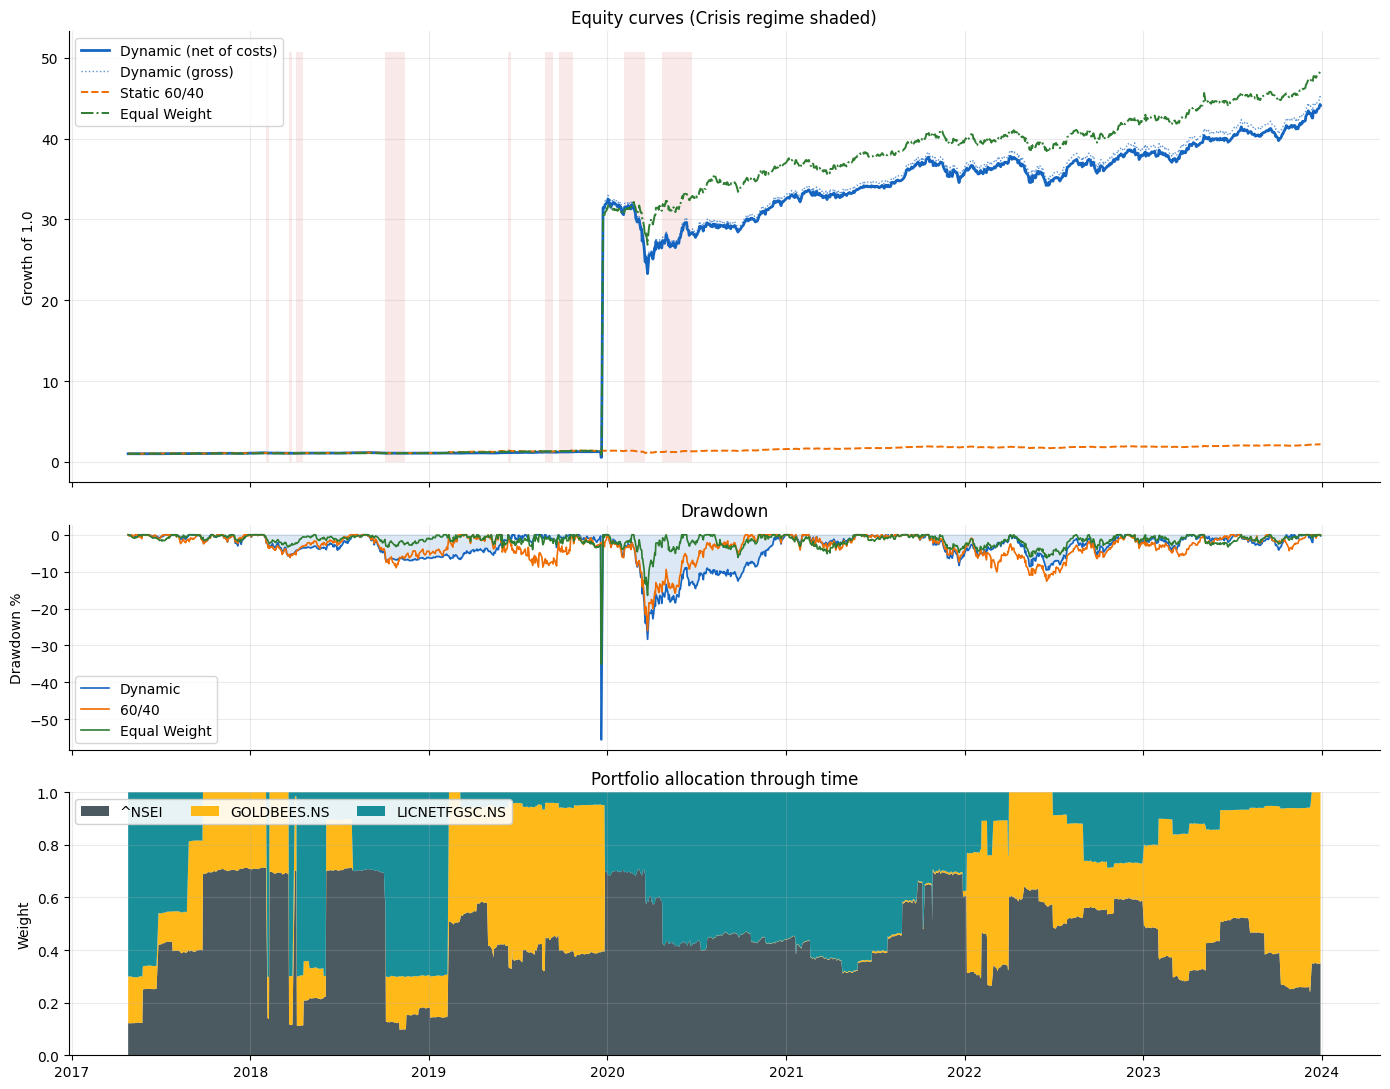


--- Mean allocation by regime ---
Ticker  ^NSEI  GOLDBEES.NS  LICNETFGSC.NS
regime                                   
Bear    0.372        0.203          0.425
Bull    0.507        0.273          0.220
Crisis  0.393        0.188          0.420


In [13]:
eq_net  = (1 + net_r).cumprod()
eq_gross = (1 + gross_r).cumprod()
eq_6040 = (1 + r_6040).cumprod()
eq_ew   = (1 + r_ew).cumprod()

fig, axes = plt.subplots(3, 1, figsize=(14, 11),
                         gridspec_kw={"height_ratios": [2.4, 1.2, 1.4]}, sharex=True)

ax = axes[0]
ax.plot(eq_net.index, eq_net, color="#1565C0", lw=2, label="Dynamic (net of costs)")
ax.plot(eq_gross.index, eq_gross, color="#1565C0", lw=1, ls=":", alpha=0.7, label="Dynamic (gross)")
ax.plot(eq_6040.index, eq_6040, color="#EF6C00", lw=1.4, ls="--", label="Static 60/40")
ax.plot(eq_ew.index, eq_ew, color="#2E7D32", lw=1.4, ls="-.", label="Equal Weight")
for code, colr in REGIME_COLOR.items():
    if code == 1:
        ax.fill_between(regimes.index[1:], 0, ax.get_ylim()[1],
                        where=(regimes.values[1:] == 1), color=colr, alpha=0.10, lw=0)
ax.set_ylabel("Growth of 1.0"); ax.set_title("Equity curves (Crisis regime shaded)")
ax.legend(loc="upper left")

ax = axes[1]
for series, lbl, colr in [(eq_net, "Dynamic", "#1565C0"), (eq_6040, "60/40", "#EF6C00"),
                          (eq_ew, "Equal Weight", "#2E7D32")]:
    dd = series / series.cummax() - 1
    ax.plot(dd.index, dd * 100, lw=1.2, color=colr, label=lbl)
ax.fill_between(eq_net.index, (eq_net / eq_net.cummax() - 1) * 100, 0, color="#1565C0", alpha=0.15)
ax.set_ylabel("Drawdown %"); ax.set_title("Drawdown"); ax.legend(loc="lower left")

ax = axes[2]
ax.stackplot(book.index, *[book[c] for c in book.columns], labels=list(book.columns),
             colors=["#37474F", "#FFB300", "#00838F"], alpha=0.9)
ax.set_ylim(0, 1); ax.set_ylabel("Weight"); ax.set_title("Portfolio allocation through time")
ax.legend(loc="upper left", ncol=3, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(); plt.show()

print("\n--- Mean allocation by regime ---")
alloc = book.copy(); alloc["regime"] = regimes.reindex(book.index).map(REGIME_NAME)
print(alloc.groupby("regime").mean().round(3).to_string())

## 12. Export artefacts

In [14]:
summary.to_csv("performance_summary.csv")
pd.DataFrame(tm_ord, index=names, columns=names).to_csv("transition_matrix.csv")
pd.concat([regimes.map(REGIME_NAME).rename("regime"), book], axis=1).to_csv("regimes_and_weights.csv")
pd.DataFrame({"gross": gross_r, "net": net_r, "bm_6040": r_6040,
              "bm_ew": r_ew, "turnover": turnover}).to_csv("daily_returns.csv")
print("Wrote: performance_summary.csv, transition_matrix.csv, regimes_and_weights.csv, daily_returns.csv")

Wrote: performance_summary.csv, transition_matrix.csv, regimes_and_weights.csv, daily_returns.csv
